# 🛒 Olist Brazilian E-Commerce — EDA Notebook
> Full exploratory data analysis across all 9 datasets

## 1. Setup

In [1]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load all 9 Olist datasets
customers     = pd.read_csv("olist_customers_dataset.csv")
geolocation   = pd.read_csv("olist_geolocation_dataset.csv")
order_items   = pd.read_csv("olist_order_items_dataset.csv")
order_payments= pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders        = pd.read_csv("olist_orders_dataset.csv")
products      = pd.read_csv("olist_products_dataset.csv")
sellers       = pd.read_csv("olist_sellers_dataset.csv")
category_name = pd.read_csv("product_category_name_translation.csv")


In [3]:
# Quick overview of all datasets — shape and column names
datasets = {
    "customers": customers, "geolocation": geolocation,
    "order_items": order_items, "order_payments": order_payments,
    "order_reviews": order_reviews, "orders": orders,
    "products": products, "sellers": sellers, "category_name": category_name
}
for name, df in datasets.items():
    print(f"{name}: {df.shape} — {list(df.columns)}")


customers: (99441, 5) — ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geolocation: (1000163, 5) — ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
order_items: (112650, 7) — ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
order_payments: (103886, 5) — ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
order_reviews: (99224, 7) — ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
orders: (99441, 8) — ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
products: (32951, 9) — ['product_id', 'product_category_name', 'product_name_lenght', 'product_des

In [4]:
# Check nulls across all datasets
for name, df in datasets.items():
    nulls = df.isnull().sum().sum()
    print(f"{name}: {nulls} total nulls")


customers: 0 total nulls
geolocation: 0 total nulls
order_items: 0 total nulls
order_payments: 0 total nulls
order_reviews: 145903 total nulls
orders: 4908 total nulls
products: 2448 total nulls
sellers: 0 total nulls
category_name: 0 total nulls


## 2. Data Cleaning

In [5]:
# Fill missing values in products table
# Category name → "unknown", numeric columns → median
products["product_category_name"] = products["product_category_name"].fillna("unknown")
products["product_name_lenght"] = products["product_name_lenght"].fillna(products["product_name_lenght"].median())
products["product_description_lenght"] = products["product_description_lenght"].fillna(products["product_description_lenght"].median())
products["product_photos_qty"] = products["product_photos_qty"].fillna(products["product_photos_qty"].median())
for col in ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]:
    products[col] = products[col].fillna(products[col].median())
products.isnull().sum()


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [6]:
# Convert all datetime columns in orders table
orders_time_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in orders_time_cols:
    orders[col] = pd.to_datetime(orders[col])


In [7]:
# Convert datetime columns in order_items table
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])


In [8]:
# Convert datetime columns in order_reviews table
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"])
order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"])


In [9]:
# Extract time features from orders table
orders["order_purchase_year"]      = orders["order_purchase_timestamp"].dt.year
orders["order_purchase_month_num"] = orders["order_purchase_timestamp"].dt.month
orders["order_purchase_month"]     = orders["order_purchase_timestamp"].dt.month_name()
orders["order_purchase_day_num"]   = orders["order_purchase_timestamp"].dt.day
orders["order_purchase_day"]       = orders["order_purchase_timestamp"].dt.day_name()
orders["order_purchase_hour"]      = orders["order_purchase_timestamp"].dt.hour


In [10]:
# Extract time features from order_items table
order_items["shipping_year"]      = order_items["shipping_limit_date"].dt.year
order_items["shipping_month_num"] = order_items["shipping_limit_date"].dt.month
order_items["shipping_month"]     = order_items["shipping_limit_date"].dt.month_name()
order_items["shipping_day"]       = order_items["shipping_limit_date"].dt.day
order_items["shipping_day_name"]  = order_items["shipping_limit_date"].dt.day_name()
order_items["shipping_hour"]      = order_items["shipping_limit_date"].dt.hour


In [11]:
# Calculate delivery time and flag late orders
orders["Delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# True if order arrived after estimated delivery date
orders["is_late"] = (
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
)


In [12]:
# Calculate approval time (purchase → approval) in hours
orders["approval_time_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600


In [13]:
# Calculate review response time in hours
order_reviews["response_time_hours"] = (
    order_reviews["review_answer_timestamp"] - order_reviews["review_creation_date"]
).dt.total_seconds() / 3600


In [14]:
# Add product volume (length × height × width)
products["product_volume_cm3"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)


In [15]:
# Merge English category names into products table (do this ONCE)
original_cols = [
    "product_id", "product_category_name", "product_name_lenght",
    "product_description_lenght", "product_photos_qty", "product_weight_g",
    "product_length_cm", "product_height_cm", "product_width_cm", "product_volume_cm3"
]
products = products[original_cols].merge(category_name, on="product_category_name", how="left")
print(products.columns.tolist())


['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_volume_cm3', 'product_category_name_english']


In [16]:
# Add freight ratio column to order_items (freight as % of item price)
order_items["freight_ratio"] = order_items["freight_value"] / order_items["price"] * 100


## 3. Customers Table

In [17]:
# Preview customers table
customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
# Count total unique customers (by unique ID, not order ID)
Total_customers = customers["customer_unique_id"].nunique()
print(f"Total unique customers: {Total_customers:,}")


Total unique customers: 96,096


In [19]:
# Count customers who ordered more than once (repeat customers)
Repeated_customers = (customers["customer_unique_id"].value_counts() > 1).sum()
print(f"Repeat customers: {Repeated_customers:,}")


Repeat customers: 2,997


In [20]:
# Calculate repeat customer rate as a percentage
repeat_rate = (Repeated_customers / Total_customers) * 100
print(f"Repeat customer rate: {repeat_rate:.2f}%")


Repeat customer rate: 3.12%


In [21]:
# Distribution of how many times customers repeat (2x, 3x, 4x...)
customers["customer_unique_id"].value_counts().value_counts().sort_index()


count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [22]:
# Count unique cities, states and zip codes
Total_cities          = customers["customer_city"].nunique()
Total_states          = customers["customer_state"].nunique()
Total_zip_code_prefix = customers["customer_zip_code_prefix"].nunique()
print(f"Cities: {Total_cities}, States: {Total_states}, Zip codes: {Total_zip_code_prefix}")


Cities: 4119, States: 27, Zip codes: 14994


In [23]:
# Unique customers per state
customers.groupby("customer_state")["customer_unique_id"].nunique()


customer_state
AC       77
AL      401
AM      143
AP       67
BA     3277
CE     1313
DF     2075
ES     1964
GO     1952
MA      726
MG    11259
MS      694
MT      876
PA      949
PB      519
PE     1609
PI      482
PR     4882
RJ    12384
RN      474
RO      240
RR       45
RS     5277
SC     3534
SE      342
SP    40302
TO      273
Name: customer_unique_id, dtype: int64

In [24]:
# Top 10 states by customer count
customers["customer_state"].value_counts().head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

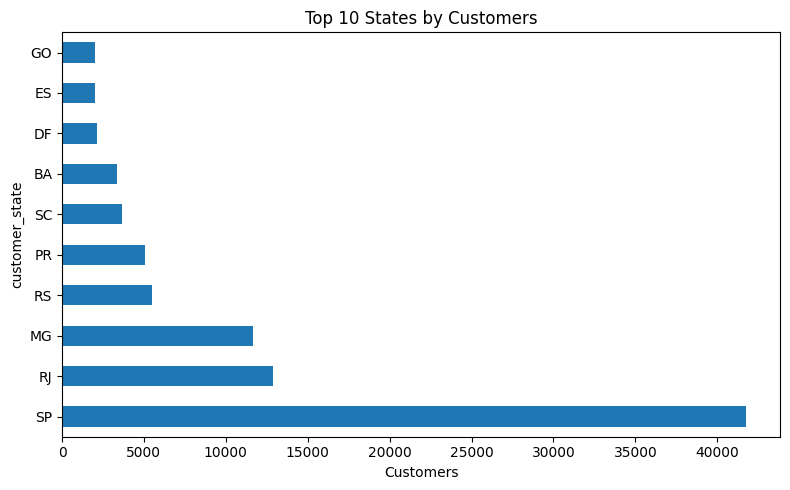

In [25]:
# Bar chart — top 10 states by customers
customers["customer_state"].value_counts().head(10).plot(
    kind="barh", title="Top 10 States by Customers", figsize=(8, 5)
)
plt.xlabel("Customers")
plt.tight_layout()
plt.show()


In [26]:
# Top 10 cities by customer count
customers["customer_city"].value_counts().head(10)


customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

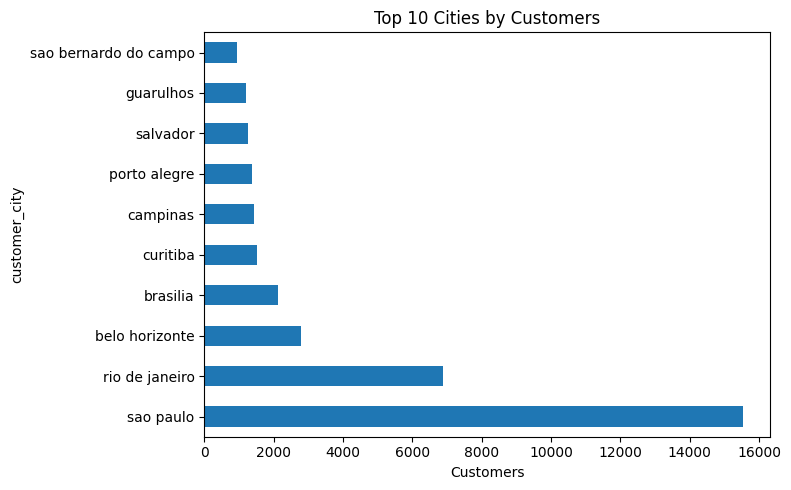

In [27]:
# Bar chart — top 10 cities by customers
customers["customer_city"].value_counts().head(10).plot(
    kind="barh", title="Top 10 Cities by Customers", figsize=(8, 5)
)
plt.xlabel("Customers")
plt.tight_layout()
plt.show()


In [28]:
# Unique customers per zip code prefix
customers.groupby("customer_zip_code_prefix")["customer_unique_id"].nunique()


customer_zip_code_prefix
1003     1
1004     2
1005     5
1006     2
1007     4
        ..
99960    2
99965    2
99970    1
99980    2
99990    1
Name: customer_unique_id, Length: 14994, dtype: int64

## 4. Geolocation Table

In [29]:
# Preview geolocation table
geolocation.head()


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [30]:
# Basic stats — total unique zip codes, cities and states in geolocation
print(f"Total zip codes: {geolocation['geolocation_zip_code_prefix'].nunique()}")
print(f"Total cities: {geolocation['geolocation_city'].nunique()}")
print(f"Total states: {geolocation['geolocation_state'].nunique()}")

# Top 10 cities by number of geolocation entries
geolocation["geolocation_city"].value_counts().head(10)


Total zip codes: 19015
Total cities: 8011
Total states: 27


geolocation_city
sao paulo                135800
rio de janeiro            62151
belo horizonte            27805
são paulo                 24918
curitiba                  16593
porto alegre              13521
salvador                  11865
guarulhos                 11340
brasilia                  10470
sao bernardo do campo      8112
Name: count, dtype: int64

## 5. Orders Table

In [31]:
# Preview orders table
orders.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_year,order_purchase_month_num,order_purchase_month,order_purchase_day_num,order_purchase_day,order_purchase_hour,Delivery_time_days,is_late,approval_time_hours
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2,Monday,10,8.0,False,0.178333
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,24,Tuesday,20,13.0,False,30.713889
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,8,Wednesday,8,9.0,False,0.276111
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,18,Saturday,19,13.0,False,0.298056
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,13,Tuesday,21,2.0,False,1.030556


In [32]:
# Total unique orders
Total_orders = orders["order_id"].nunique()
print(f"Total orders: {Total_orders:,}")


Total orders: 99,441


In [33]:
# Number of distinct order statuses
Total_order_status_number = orders["order_status"].nunique()
print(f"Total status types: {Total_order_status_number}")


Total status types: 8


In [34]:
# Count of orders per status
order_status_counts = orders["order_status"].value_counts()
print(order_status_counts)


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


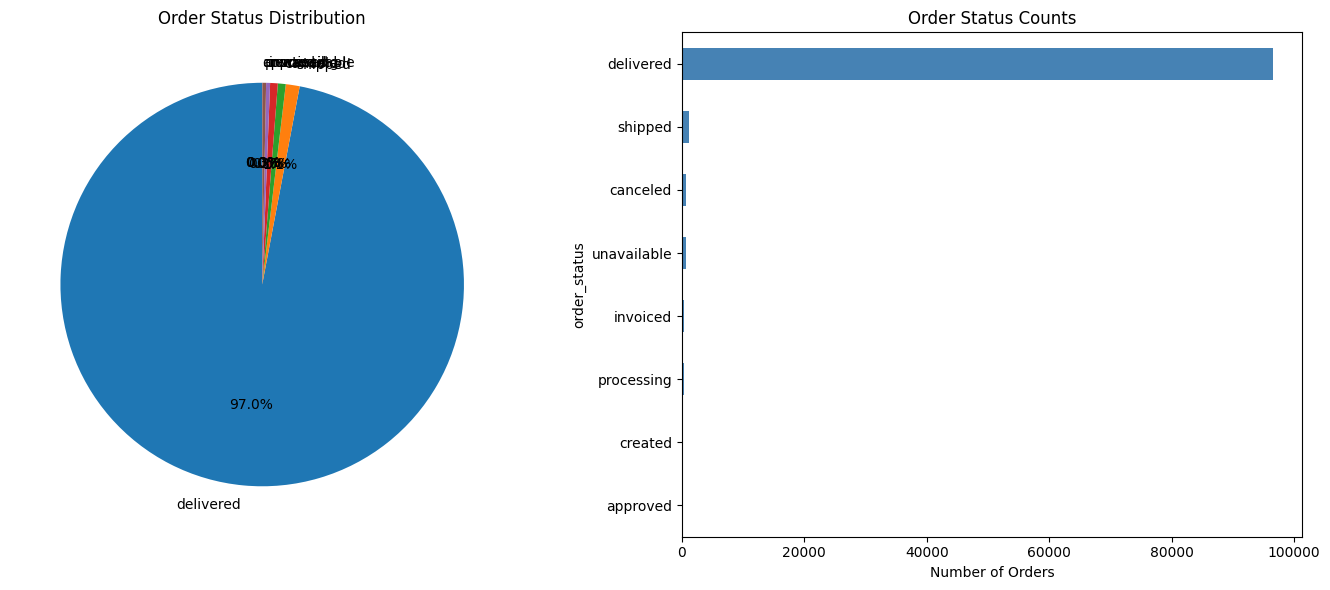

In [35]:
# Pie chart — order status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order_status_counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[0],
    title="Order Status Distribution", startangle=90)
axes[0].set_ylabel("")
order_status_counts.sort_values().plot(kind="barh", ax=axes[1],
    title="Order Status Counts", color="steelblue")
axes[1].set_xlabel("Number of Orders")
plt.tight_layout()
plt.show()


In [36]:
# Total orders per year
yearly_orders = orders.groupby("order_purchase_year")["order_id"].nunique().reset_index(name="total_orders")
print(yearly_orders)


   order_purchase_year  total_orders
0                 2016           329
1                 2017         45101
2                 2018         54011


In [37]:
# Monthly order counts grouped by year
monthly_orders = (
    orders.groupby(["order_purchase_year", "order_purchase_month"])
    .size()
    .reset_index(name="total_orders")
)


In [38]:
# Top selling month per year
top_month_per_year = monthly_orders.loc[
    monthly_orders.groupby("order_purchase_year")["total_orders"].idxmax()
]
print(top_month_per_year)


    order_purchase_year order_purchase_month  total_orders
1                  2016              October           324
12                 2017             November          7544
18                 2018              January          7269


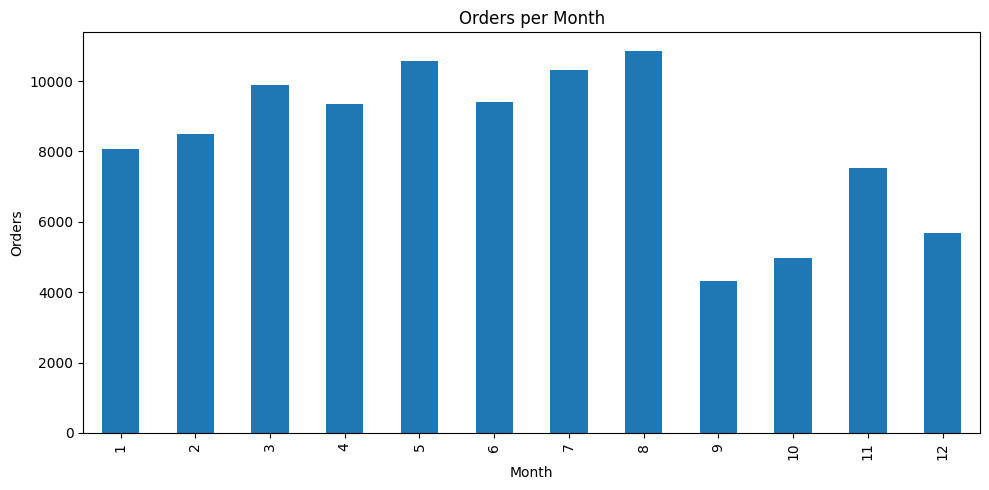

In [39]:
# Bar chart — orders per month (all years combined)
orders.groupby("order_purchase_month_num")["order_id"].count().plot(
    kind="bar", title="Orders per Month", figsize=(10, 5)
)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()


In [40]:
# Delivery time stats — how fast are orders delivered on average
orders["Delivery_time_days"].dropna().describe().round(2)


count    96476.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: Delivery_time_days, dtype: float64

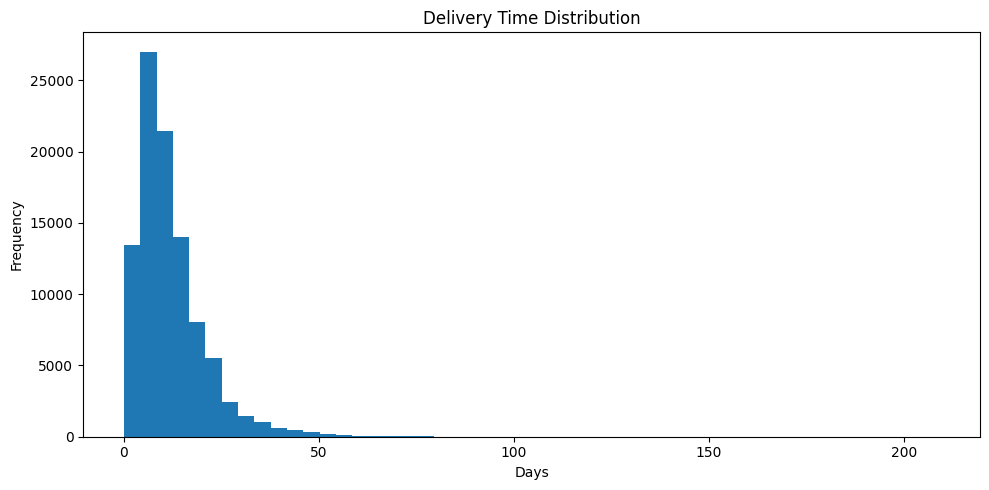

In [41]:
# Histogram — delivery time distribution in days
orders["Delivery_time_days"].dropna().plot(
    kind="hist", bins=50, title="Delivery Time Distribution", figsize=(10, 5)
)
plt.xlabel("Days")
plt.tight_layout()
plt.show()


In [42]:
# How many orders were delivered late
print(f"Late orders: {orders['is_late'].sum():,}")
print(f"Late delivery rate: {orders['is_late'].mean()*100:.2f}%")


Late orders: 7,827
Late delivery rate: 7.87%


In [43]:
# Approval time stats — how long from purchase to approval
orders["approval_time_hours"].describe().round(2)


count    99281.00
mean        10.42
std         26.04
min          0.00
25%          0.22
50%          0.34
75%         14.58
max       4509.18
Name: approval_time_hours, dtype: float64

In [44]:
# Orders per day of week
orders["order_purchase_day"].value_counts()


order_purchase_day
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: count, dtype: int64

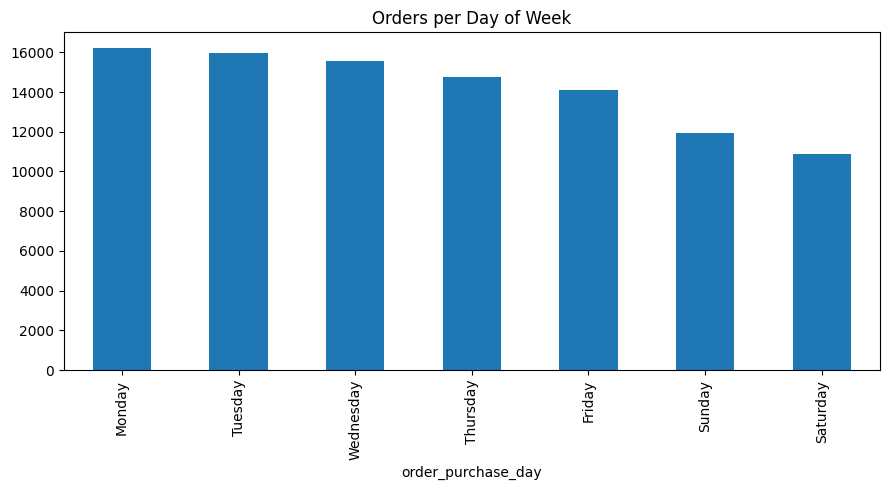

In [45]:
# Bar chart — orders per day of week
orders["order_purchase_day"].value_counts().plot(
    kind="bar", title="Orders per Day of Week", figsize=(9, 5)
)
plt.tight_layout()
plt.show()


In [46]:
# Orders per hour of day
orders["order_purchase_hour"].value_counts().sort_index()


order_purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64

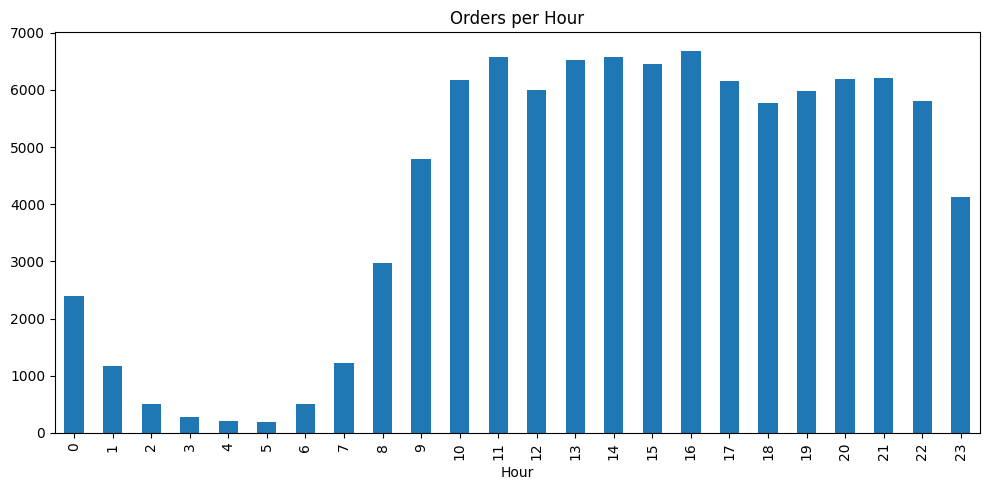

In [47]:
# Bar chart — orders per hour of day (peak shopping hours)
orders["order_purchase_hour"].value_counts().sort_index().plot(
    kind="bar", title="Orders per Hour", figsize=(10, 5)
)
plt.xlabel("Hour")
plt.tight_layout()
plt.show()


In [48]:
# Total orders per year
orders.groupby("order_purchase_year")["order_id"].count()


order_purchase_year
2016      329
2017    45101
2018    54011
Name: order_id, dtype: int64

In [49]:
# Cancellation rate
cancelled = (orders["order_status"] == "canceled").sum()
print(f"Cancellation rate: {cancelled/Total_orders*100:.2f}%")


Cancellation rate: 0.63%


## 6. Order Items Table

In [50]:
# Preview order items table
order_items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_year,shipping_month_num,shipping_month,shipping_day,shipping_day_name,shipping_hour,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017,9,September,19,Tuesday,9,22.563667
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017,5,May,3,Wednesday,11,8.307628
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018,1,January,18,Thursday,14,8.979899
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018,8,August,15,Wednesday,10,98.460354
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017,2,February,13,Monday,13,9.074537


In [51]:
# Total number of items sold across all orders
Total_items_sold = len(order_items)
print(f"Total items sold: {Total_items_sold:,}")


Total items sold: 112,650


In [52]:
# Price statistics — min, max, mean, distribution
order_items["price"].describe().round(2)


count    112650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max        6735.00
Name: price, dtype: float64

In [53]:
# Freight value statistics
order_items["freight_value"].describe().round(2)


count    112650.00
mean         19.99
std          15.81
min           0.00
25%          13.08
50%          16.26
75%          21.15
max         409.68
Name: freight_value, dtype: float64

In [54]:
# Freight ratio stats — what % of item price goes to freight
order_items["freight_ratio"].describe().round(2)


count    112650.00
mean         32.09
std          34.99
min           0.00
25%          13.40
50%          23.14
75%          39.30
max        2623.53
Name: freight_ratio, dtype: float64

In [55]:
# Orders by shipping month
order_items["shipping_month"].value_counts().sort_index(ascending=False)


shipping_month
September     4827
October       5554
November      7355
May          12915
March        11510
June         10698
July         10788
January       8173
February      9243
December      7727
August       13857
April        10003
Name: count, dtype: int64

In [56]:
# Total revenue from all items
total_revenue = order_items["price"].sum()
print(f"Total Revenue: R$ {total_revenue:,.2f}")


Total Revenue: R$ 13,591,643.70


In [57]:
# Total freight collected
total_freight = order_items["freight_value"].sum()
print(f"Total Freight: R$ {total_freight:,.2f}")


Total Freight: R$ 2,251,909.54


In [58]:
# Items per order — how many items are in each order on average
items_per_order = order_items.groupby("order_id")["order_item_id"].max()
items_per_order.describe().round(2)


count    98666.00
mean         1.14
std          0.54
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         21.00
Name: order_item_id, dtype: float64

In [59]:
# How many orders contained more than 1 item
(items_per_order > 1).sum()


np.int64(9803)

In [60]:
# Total unique sellers
print(f"Total sellers: {order_items['seller_id'].nunique():,}")


Total sellers: 3,095


In [61]:
# Top 10 sellers by number of items sold
order_items["seller_id"].value_counts().head(10)


seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

In [62]:
# Top 10 sellers by total revenue
order_items.groupby("seller_id")["price"].sum().sort_values(ascending=False).head(10)


seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [63]:
# Price bucket distribution — how orders are distributed across price ranges
bins   = [0, 50, 100, 250, 500, float("inf")]
labels = ["<50", "50-100", "100-250", "250-500", "500+"]
pd.cut(order_items["price"], bins=bins, labels=labels).value_counts().sort_index()


price
<50        39317
50-100     33020
100-250    30788
250-500     6309
500+        3216
Name: count, dtype: int64

## 7. Order Payments Table

In [64]:
# Preview order payments table
order_payments.head(10)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [65]:
# Total unique orders with payment records
print(f"Total orders: {order_payments['order_id'].nunique():,}")


Total orders: 99,440


In [66]:
# Payment value statistics
order_payments["payment_value"].describe().round(2)


count    103886.00
mean        154.10
std         217.49
min           0.00
25%          56.79
50%         100.00
75%         171.84
max       13664.08
Name: payment_value, dtype: float64

In [67]:
# Count of each payment type
order_payments["payment_type"].value_counts()


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

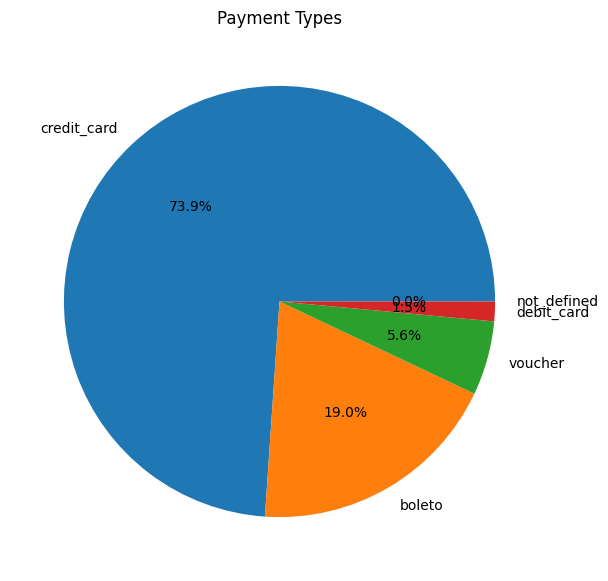

In [68]:
# Pie chart — payment type distribution
order_payments["payment_type"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", title="Payment Types", figsize=(7, 7)
)
plt.ylabel("")
plt.show()


In [69]:
# Total revenue per payment type
order_payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)


payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

In [70]:
# Average payment value per payment type
order_payments.groupby("payment_type")["payment_value"].mean().round(2)


payment_type
boleto         145.03
credit_card    163.32
debit_card     142.57
not_defined      0.00
voucher         65.70
Name: payment_value, dtype: float64

In [71]:
# Distribution of installment counts
order_payments["payment_installments"].value_counts().sort_index()


payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

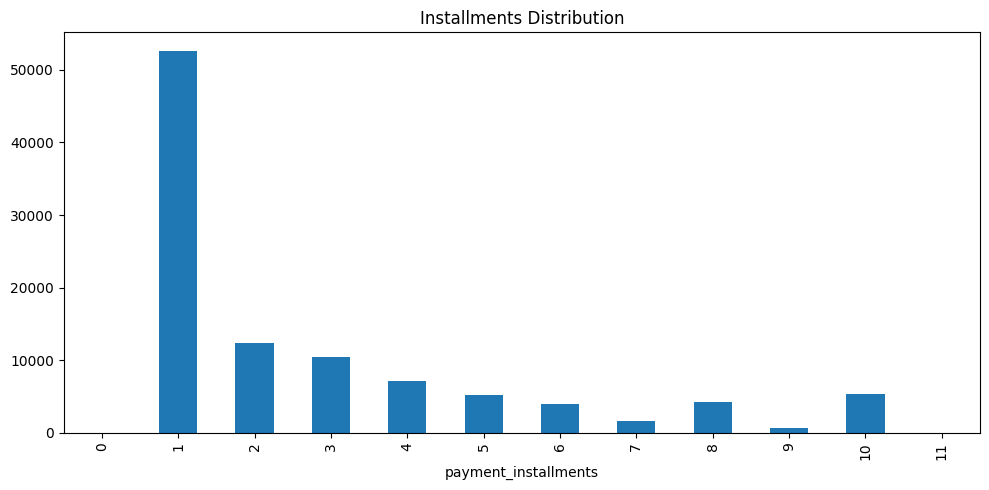

In [72]:
# Bar chart — installments distribution (top 12)
order_payments["payment_installments"].value_counts().sort_index().head(12).plot(
    kind="bar", title="Installments Distribution", figsize=(10, 5)
)
plt.tight_layout()
plt.show()


In [73]:
# Most common number of installments
print(f"Most common: {order_payments['payment_installments'].mode()[0]} installments")


Most common: 1 installments


In [74]:
# Average installments per payment type
order_payments.groupby("payment_type")["payment_installments"].mean().round(2)


payment_type
boleto         1.00
credit_card    3.51
debit_card     1.00
not_defined    1.00
voucher        1.00
Name: payment_installments, dtype: float64

In [75]:
# Orders that used more than one payment method
multi_payment_orders = order_payments[order_payments["payment_sequential"] > 1]
print(f"Orders with multiple payments: {multi_payment_orders['order_id'].nunique():,}")


Orders with multiple payments: 3,039


In [76]:
# Max payment sequences used in a single order
order_payments.groupby("order_id")["payment_sequential"].max().value_counts()


payment_sequential
1     96401
2      2458
3       303
4       108
5        52
6        36
7        28
8        11
9         9
11        8
12        8
10        5
13        3
15        2
14        2
19        2
22        1
21        1
26        1
29        1
Name: count, dtype: int64

In [77]:
# Payment value bucket distribution
bins   = [0, 50, 100, 250, 500, float("inf")]
labels = ["<50", "50-100", "100-250", "250-500", "500+"]
pd.cut(order_payments["payment_value"], bins=bins, labels=labels).value_counts().sort_index()


payment_value
<50        21393
50-100     30708
100-250    38193
250-500     9327
500+        4256
Name: count, dtype: int64

## 8. Order Reviews Table

In [78]:
# Preview order reviews table
order_reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,response_time_hours
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,21.783056
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,27.086944
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,38.606667
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,22.035000
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,34.448056


In [79]:
# Total reviews and unique orders reviewed
print(f"Total reviews: {len(order_reviews):,}")
print(f"Unique orders reviewed: {order_reviews['order_id'].nunique():,}")


Total reviews: 99,224
Unique orders reviewed: 98,673


In [80]:
# Review score distribution (count per score 1-5)
order_reviews["review_score"].value_counts().sort_index()


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

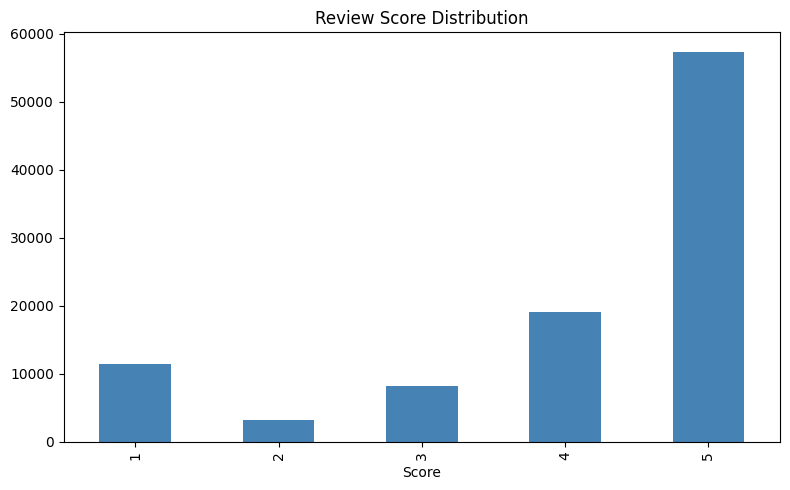

In [81]:
# Bar chart — review score distribution
order_reviews["review_score"].value_counts().sort_index().plot(
    kind="bar", title="Review Score Distribution", figsize=(8, 5), color="steelblue"
)
plt.xlabel("Score")
plt.tight_layout()
plt.show()


In [82]:
# Average review score
print(f"Average review score: {order_reviews['review_score'].mean():.2f}")


Average review score: 4.09


In [83]:
# Percentage of each score
order_reviews["review_score"].value_counts(normalize=True).sort_index() * 100


review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

In [84]:
# Segment reviews into Positive / Neutral / Negative
bins   = [0, 2, 3, 5]
labels = ["Negative (1-2)", "Neutral (3)", "Positive (4-5)"]
pd.cut(order_reviews["review_score"], bins=bins, labels=labels).value_counts()


review_score
Positive (4-5)    76470
Negative (1-2)    14575
Neutral (3)        8179
Name: count, dtype: int64

In [85]:
# How many reviews include a comment message
has_message = order_reviews["review_comment_message"].notna().sum()
print(f"Reviews with comments: {has_message:,}")
print(f"Comment rate: {has_message/len(order_reviews)*100:.1f}%")


Reviews with comments: 40,977
Comment rate: 41.3%


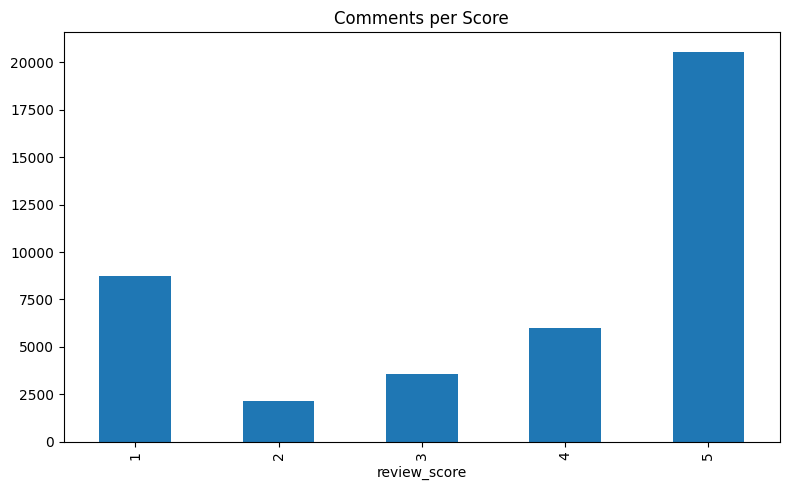

In [86]:
# Bar chart — number of comments per score (1-star customers write more)
order_reviews.groupby("review_score")["review_comment_message"].apply(
    lambda x: x.notna().sum()
).plot(kind="bar", title="Comments per Score", figsize=(8, 5))
plt.tight_layout()
plt.show()


In [87]:
# How many reviews include a title
has_title = order_reviews["review_comment_title"].notna().sum()
print(f"Reviews with title: {has_title:,}")


Reviews with title: 11,568


In [88]:
# Average review response time per score
order_reviews.groupby("review_score")["response_time_hours"].mean().round(2)


review_score
1    73.22
2    72.10
3    71.55
4    74.89
5    77.04
Name: response_time_hours, dtype: float64

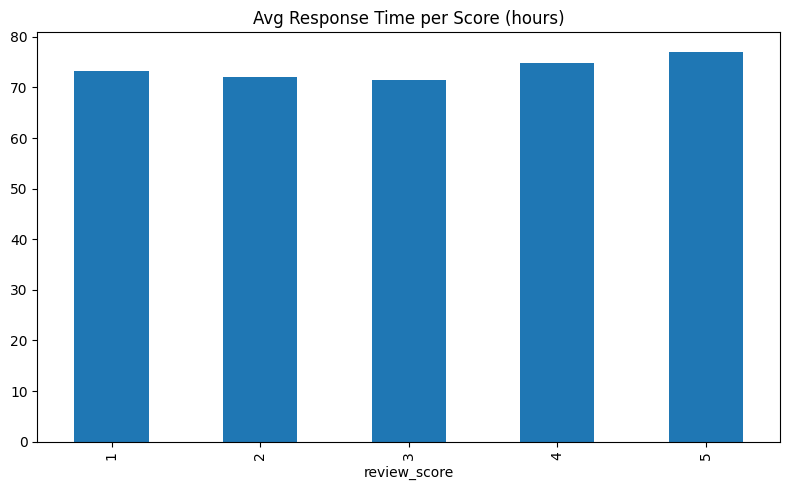

In [89]:
# Bar chart — avg response time per score
order_reviews.groupby("review_score")["response_time_hours"].mean().plot(
    kind="bar", title="Avg Response Time per Score (hours)", figsize=(8, 5)
)
plt.tight_layout()
plt.show()


In [90]:
# Reviews per month
order_reviews["review_month"] = order_reviews["review_creation_date"].dt.month_name()
order_reviews["review_month"].value_counts()


review_month
August       13490
May          11168
March        10284
June         10155
April         9342
July          9137
December      8027
February      7514
January       6418
November      4887
October       4603
September     4199
Name: count, dtype: int64

## 9. Products Table

In [91]:
# Preview products table
products.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,2240.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,10800.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,2430.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,2704.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,4420.0,housewares


In [92]:
# Total unique products and categories
print(f"Total products: {products['product_id'].nunique():,}")
print(f"Total categories (Portuguese): {products['product_category_name'].nunique()}")


Total products: 32,951
Total categories (Portuguese): 74


In [93]:
# Physical dimensions statistics — weight, size
products[["product_weight_g", "product_length_cm",
          "product_height_cm", "product_width_cm"]].describe().round(2)


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.00,32951.00,32951.00,32951.00
mean,2276.38,30.81,16.94,23.20
std,4281.93,16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00


In [94]:
# Top 10 categories by number of products
products["product_category_name_english"].value_counts().head(10)


product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

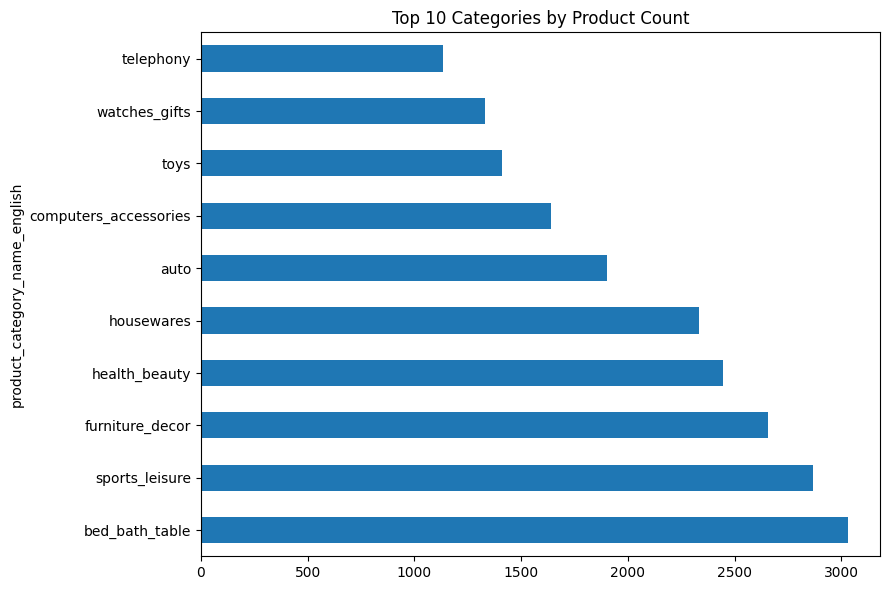

In [95]:
# Bar chart — top 10 product categories
products["product_category_name_english"].value_counts().head(10).plot(
    kind="barh", title="Top 10 Categories by Product Count", figsize=(9, 6)
)
plt.tight_layout()
plt.show()


In [96]:
# Bottom 10 categories (least products)
products["product_category_name_english"].value_counts().tail(10)


product_category_name_english
fashion_sport                        19
flowers                              14
diapers_and_hygiene                  12
la_cuisine                           10
furniture_mattress_and_upholstery    10
tablets_printing_image                9
fashion_childrens_clothes             5
home_comfort_2                        5
security_and_services                 2
cds_dvds_musicals                     1
Name: count, dtype: int64

In [97]:
# Average name and description length per category
products.groupby("product_category_name")[
    ["product_name_lenght", "product_description_lenght"]
].mean().round(2).sort_values("product_description_lenght", ascending=False).head(10)


,product_name_lenght,product_description_lenght
product_category_name,,
pcs,55.53,2128.83
moveis_escritorio,46.13,1352.77
livros_tecnicos,41.97,1351.53
beleza_saude,47.21,1136.93
alimentos,46.30,1136.51
construcao_ferramentas_jardim,48.22,1134.90
moveis_colchao_e_estofado,43.20,1111.30
construcao_ferramentas_seguranca,52.05,1105.82
industria_comercio_e_negocios,52.87,1102.65


In [98]:
# Average number of product photos per category
products.groupby("product_category_name")["product_photos_qty"].mean().round(2)\
        .sort_values(ascending=False).head(10)


product_category_name
fashion_calcados                  5.12
pc_gamer                          4.33
casa_construcao                   3.27
fashion_underwear_e_moda_praia    3.26
fashion_roupa_infanto_juvenil     3.20
tablets_impressao_imagem          3.00
artes_e_artesanato                3.00
telefonia_fixa                    2.99
fashion_bolsas_e_acessorios       2.94
instrumentos_musicais             2.85
Name: product_photos_qty, dtype: float64

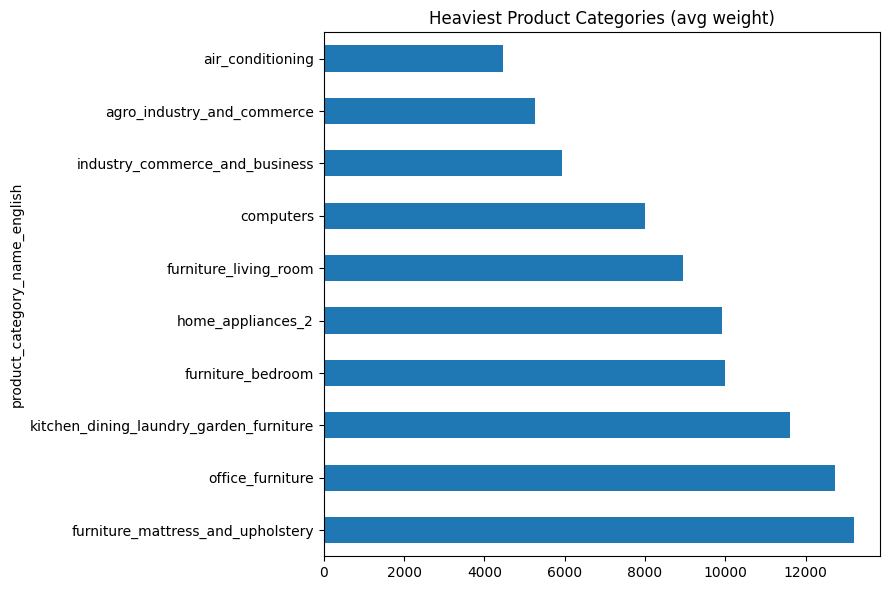

In [99]:
# Heaviest categories on average (by weight)
products.groupby("product_category_name_english")["product_weight_g"].mean()\
        .sort_values(ascending=False).head(10).plot(
    kind="barh", title="Heaviest Product Categories (avg weight)", figsize=(9, 6)
)
plt.tight_layout()
plt.show()


In [100]:
# Top 10 largest products by volume (cm³)
products.nlargest(10, "product_volume_cm3")[
    ["product_category_name_english", "product_volume_cm3", "product_weight_g"]
]


,product_category_name_english,product_volume_cm3,product_weight_g
12802,housewares,296208.0,25250.0
10697,furniture_decor,294000.0,14000.0
12146,furniture_living_room,294000.0,30000.0
17303,furniture_living_room,294000.0,30000.0
25524,furniture_living_room,294000.0,30000.0
32532,furniture_living_room,293706.0,30000.0
3770,furniture_living_room,288000.0,30000.0
7234,furniture_living_room,288000.0,30000.0
16728,furniture_living_room,288000.0,30000.0
28145,furniture_living_room,287980.0,30000.0


## 10. Sellers Table

In [101]:
# Preview sellers table
sellers.head()


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [102]:
# Total unique sellers, cities and states
print(f"Total sellers: {sellers['seller_id'].nunique():,}")
print(f"Total cities: {sellers['seller_city'].nunique():,}")
print(f"Total states: {sellers['seller_state'].nunique()}")


Total sellers: 3,095
Total cities: 611
Total states: 23


In [103]:
# Top 10 seller cities
sellers["seller_city"].value_counts().head(10)


seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: count, dtype: int64

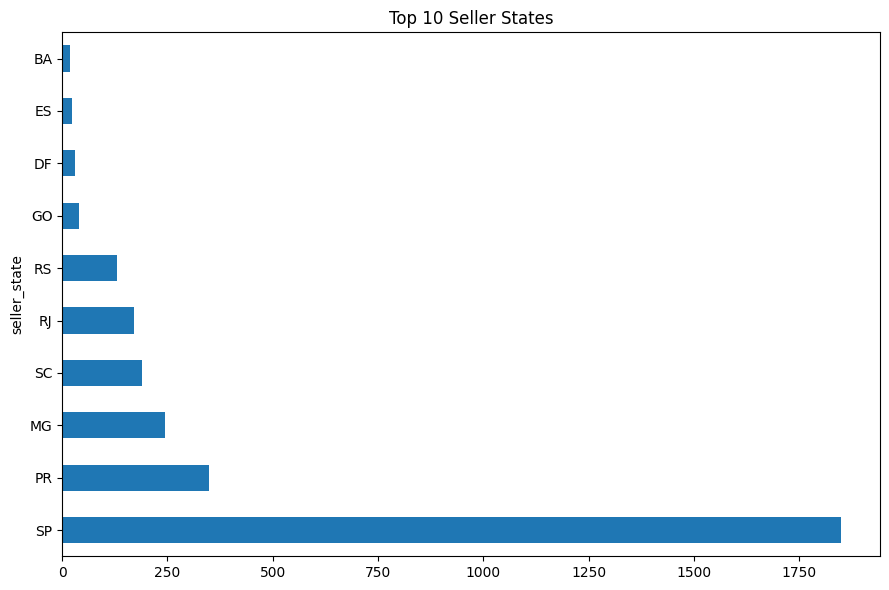

In [104]:
# Bar chart — top 10 seller states
sellers["seller_state"].value_counts().head(10).plot(
    kind="barh", title="Top 10 Seller States", figsize=(9, 6)
)
plt.tight_layout()
plt.show()


In [105]:
# All sellers per state
sellers["seller_state"].value_counts()


seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [106]:
# Build seller performance table — orders fulfilled + revenue per seller
seller_orders   = order_items.groupby("seller_id")["order_id"].count().reset_index(name="total_orders")
seller_revenue  = order_items.groupby("seller_id")["price"].sum().reset_index(name="total_revenue")
seller_performance = sellers.merge(seller_orders, on="seller_id").merge(seller_revenue, on="seller_id")
seller_performance.sort_values("total_revenue", ascending=False).head(10)


,seller_id,seller_zip_code_prefix,seller_city,seller_state,total_orders,total_revenue
2617,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,1156,229472.63
901,53243585a1d6dc2643021fd1853d8905,42738,lauro de freitas,BA,410,222776.05
2463,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,1987,200472.92
557,fa1c13f2614d7b5c4749cbc52fecda94,13170,sumare,SP,586,194042.03
1182,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,1364,187923.89
68,7e93a43ef30c4f03f38b393420bc753a,6429,barueri,SP,340,176431.87
1873,da8622b14eb17ae2831f4ac5b9dab84a,13405,piracicaba,SP,1551,160236.57
2207,7a67c85e85bb2ce8582c35f2203ad736,3426,sao paulo,SP,1171,141745.53
2720,1025f0e2d44d7041d6cf58b6550e0bfa,3204,sao paulo,SP,1428,138968.55
390,955fee9216a65b617aa5c0531780ce60,4782,sao paulo,SP,1499,135171.70


In [107]:
# Total revenue per seller state
seller_performance.groupby("seller_state")["total_revenue"].sum().sort_values(ascending=False)


seller_state
SP    8753396.21
PR    1261887.21
MG    1011564.74
RJ     843984.22
SC     632426.07
RS     378559.54
BA     285561.56
DF      97749.48
PE      91493.85
GO      66399.21
ES      47689.61
MA      36408.95
CE      20240.64
PB      17095.00
MT      17070.72
RN       9992.60
MS       8551.69
RO       4762.20
PI       2522.00
SE       1606.20
PA       1238.00
AM       1177.00
AC        267.00
Name: total_revenue, dtype: float64

In [108]:
# Revenue concentration — top 10% of sellers generate what % of total revenue
top_10_percent     = int(len(seller_performance) * 0.1)
top_sellers_rev    = seller_performance.nlargest(top_10_percent, "total_revenue")["total_revenue"].sum()
total_rev          = seller_performance["total_revenue"].sum()
print(f"Top 10% sellers generate {top_sellers_rev/total_rev*100:.1f}% of revenue")


Top 10% sellers generate 67.5% of revenue


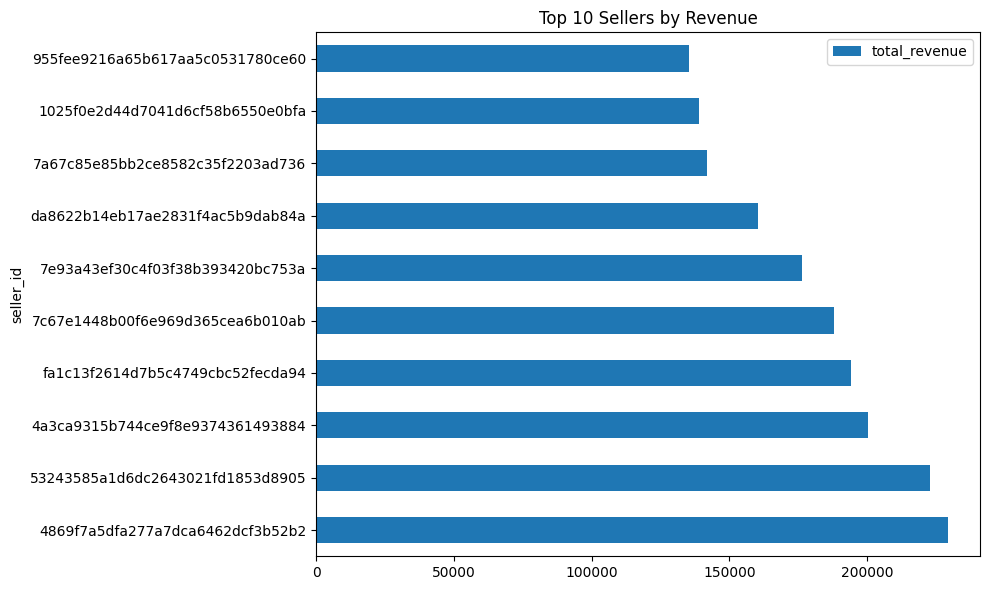

In [109]:
# Bar chart — top 10 sellers by revenue
seller_performance.nlargest(10, "total_revenue").plot(
    kind="barh", x="seller_id", y="total_revenue",
    title="Top 10 Sellers by Revenue", figsize=(10, 6)
)
plt.tight_layout()
plt.show()


## 11. Category Name Translation

In [110]:
# Preview category name translation table
category_name.head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [111]:
# Total categories available for translation
print(f"Total categories: {len(category_name)}")


Total categories: 71


## 12. Cross-Table Analysis — Business Insights

In [112]:
# 1. Do late deliveries cause bad reviews?
# Merge orders with reviews, then compare avg score for late vs on-time
orders_reviews = orders.merge(order_reviews, on="order_id", how="inner")
orders_reviews.groupby("is_late")["review_score"].mean().round(2)


is_late
False    4.21
True     2.57
Name: review_score, dtype: float64

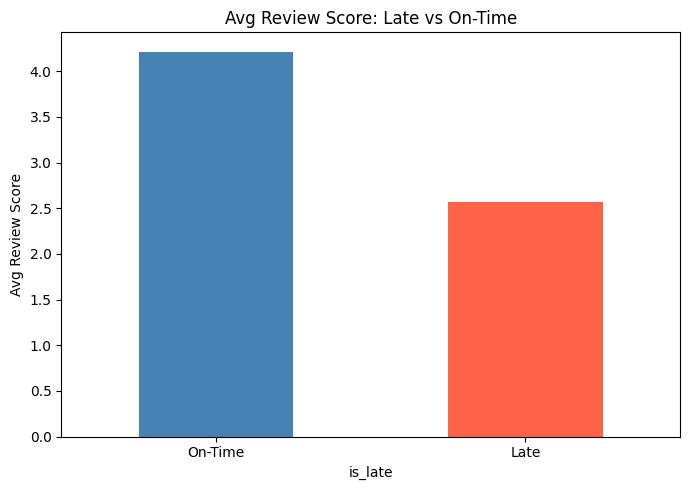

In [113]:
# Bar chart — late vs on-time avg review score
orders_reviews.groupby("is_late")["review_score"].mean().plot(
    kind="bar", title="Avg Review Score: Late vs On-Time", figsize=(7, 5),
    color=["steelblue", "tomato"]
)
plt.ylabel("Avg Review Score")
plt.xticks([0, 1], ["On-Time", "Late"], rotation=0)
plt.tight_layout()
plt.show()


In [114]:
# 2. Most used payment type per year
orders.merge(order_payments, on="order_id").groupby(
    ["order_purchase_year", "payment_type"]
)["order_id"].count()


order_purchase_year  payment_type
2016                 boleto             63
                     credit_card       258
                     debit_card          2
                     voucher            23
2017                 boleto           9508
                     credit_card     34568
                     debit_card        422
                     voucher          3027
2018                 boleto          10213
                     credit_card     41969
                     debit_card       1105
                     not_defined         3
                     voucher          2725
Name: order_id, dtype: int64

In [115]:
# 3. Which product categories get the worst reviews?
# Merge orders + items + reviews + products to link category to review score
full = (
    orders.merge(order_items, on="order_id")
          .merge(order_reviews, on="order_id")
          .merge(products[["product_id", "product_category_name_english"]], on="product_id")
)
full.groupby("product_category_name_english")["review_score"].mean().round(2).sort_values().head(10)


product_category_name_english
security_and_services                2.50
diapers_and_hygiene                  3.26
office_furniture                     3.49
home_comfort_2                       3.63
fashion_male_clothing                3.64
fixed_telephony                      3.68
party_supplies                       3.77
fashio_female_clothing               3.78
furniture_mattress_and_upholstery    3.82
home_confort                         3.83
Name: review_score, dtype: float64

In [116]:
# 4. Which states spend the most? (customers + orders + payments)
customers.merge(orders, on="customer_id").merge(order_payments, on="order_id")\
         .groupby("customer_state")["payment_value"].sum().sort_values(ascending=False)


customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
PE     324850.44
CE     279464.03
PA     218295.85
MT     187029.29
MA     152523.02
PB     141545.72
MS     137534.84
PI     108523.97
RN     102718.13
AL      96962.06
SE      75246.25
TO      61485.33
RO      60866.20
AM      27966.93
AC      19680.62
AP      16262.80
RR      10064.62
Name: payment_value, dtype: float64

In [117]:
# 5. Best selling categories by total revenue
order_items.merge(products[["product_id", "product_category_name_english"]], on="product_id")\
           .groupby("product_category_name_english")["price"].sum()\
           .sort_values(ascending=False).head(10)


product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

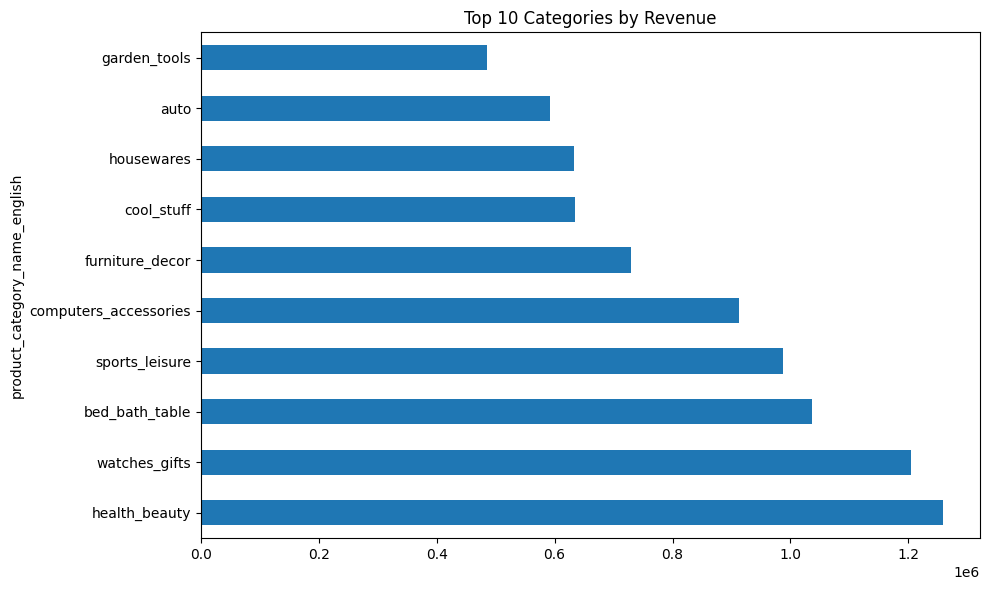

In [118]:
# Bar chart — top 10 categories by revenue
order_items.merge(products[["product_id", "product_category_name_english"]], on="product_id")\
           .groupby("product_category_name_english")["price"].sum()\
           .sort_values(ascending=False).head(10)\
           .plot(kind="barh", title="Top 10 Categories by Revenue", figsize=(10, 6))
plt.tight_layout()
plt.show()


In [119]:
# 6. Do heavier products cost more to ship? (correlation check)
order_items.merge(products[["product_id", "product_weight_g"]], on="product_id")\
           [["product_weight_g", "freight_value"]].corr()


,product_weight_g,freight_value
product_weight_g,1.000000,0.610423
freight_value,0.610423,1.000000


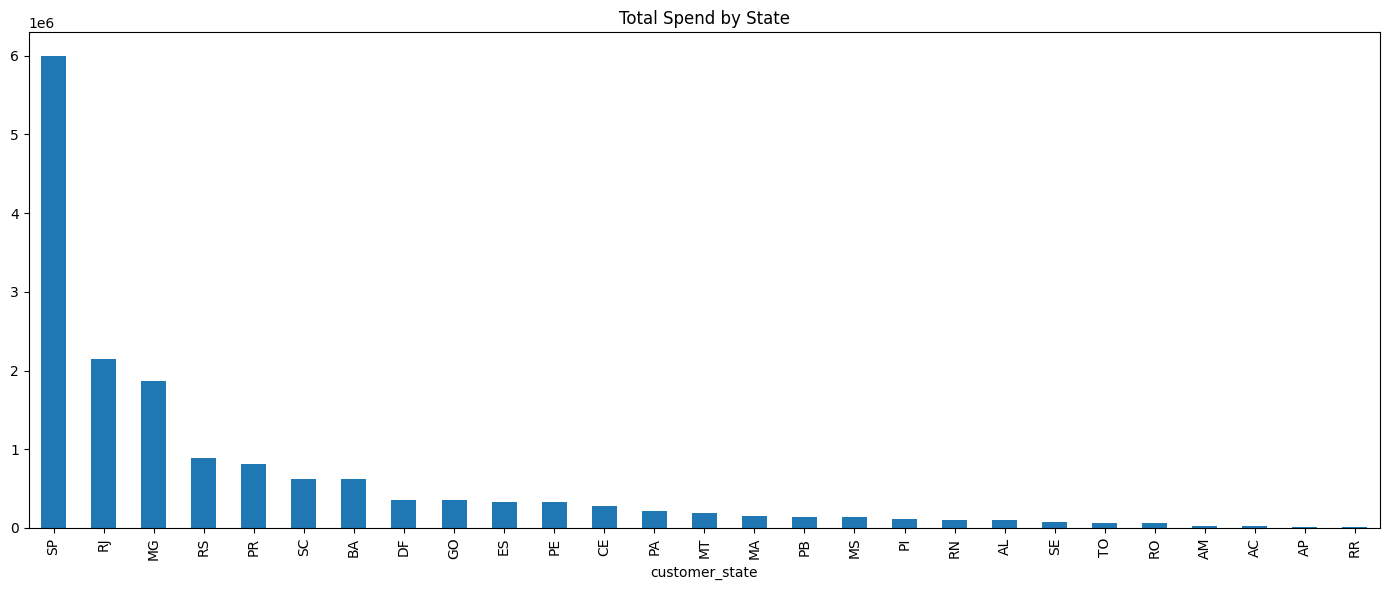

In [120]:
# Bar chart — total spend per customer state
customers.merge(orders, on="customer_id").merge(order_payments, on="order_id")\
         .groupby("customer_state")["payment_value"].sum()\
         .sort_values(ascending=False)\
         .plot(kind="bar", title="Total Spend by State", figsize=(14, 6))
plt.tight_layout()
plt.show()


## 13. Business Summary

In [121]:
# Full business summary — all key KPIs in one cell
print("=" * 45)
print("        OLIST BUSINESS SUMMARY")
print("=" * 45)
print(f"Total Customers:        {Total_customers:,}")
print(f"Total Orders:           {Total_orders:,}")
print(f"Total Items Sold:       {Total_items_sold:,}")
print(f"Total Revenue:          R$ {total_revenue:,.2f}")
print(f"Total Freight:          R$ {total_freight:,.2f}")
print(f"Repeat Customer Rate:   {repeat_rate:.2f}%")
print(f"Late Delivery Rate:     {orders['is_late'].mean()*100:.2f}%")
print(f"Avg Review Score:       {order_reviews['review_score'].mean():.2f}/5")
print(f"Total Sellers:          {sellers['seller_id'].nunique():,}")
print(f"Total Products:         {products['product_id'].nunique():,}")
print(f"Total Categories:       {products['product_category_name_english'].nunique()}")
print("=" * 45)


        OLIST BUSINESS SUMMARY
Total Customers:        96,096
Total Orders:           99,441
Total Items Sold:       112,650
Total Revenue:          R$ 13,591,643.70
Total Freight:          R$ 2,251,909.54
Repeat Customer Rate:   3.12%
Late Delivery Rate:     7.87%
Avg Review Score:       4.09/5
Total Sellers:          3,095
Total Products:         32,951
Total Categories:       71


## 14. Power BI Export
> Export clean, analysis-ready tables for building the dashboard in Power BI

In [122]:
# Build the master fact table — joins all key tables into one
# This is the main table for Power BI — one row per order item
master = (
    orders.merge(customers, on="customer_id", how="left")
          .merge(order_items, on="order_id", how="left")
          .merge(order_payments, on="order_id", how="left")
          .merge(order_reviews[["order_id", "review_score", "response_time_hours"]], on="order_id", how="left")
          .merge(products[["product_id", "product_category_name_english", "product_weight_g", "product_volume_cm3"]], on="product_id", how="left")
          .merge(sellers[["seller_id", "seller_state", "seller_city"]], on="seller_id", how="left")
)
print(f"Master table shape: {master.shape}")
master.head()


Master table shape: (119143, 45)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_year,order_purchase_month_num,...,payment_type,payment_installments,payment_value,review_score,response_time_hours,product_category_name_english,product_weight_g,product_volume_cm3,seller_state,seller_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,credit_card,1.0,18.12,4.0,27.730000,housewares,500.0,1976.0,SP,maua
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,voucher,1.0,2.00,4.0,27.730000,housewares,500.0,1976.0,SP,maua
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,voucher,1.0,18.59,4.0,27.730000,housewares,500.0,1976.0,SP,maua
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,boleto,1.0,141.46,4.0,18.630556,perfumery,400.0,4693.0,SP,belo horizonte
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,credit_card,3.0,179.12,5.0,115.132778,auto,420.0,9576.0,SP,guariba


In [131]:
# Export master fact table
master.to_csv("powerbi_master.csv", index=False)
print(" powerbi_master.csv exported")


 powerbi_master.csv exported


In [132]:
# Export clean orders table (with all computed columns)
orders.to_csv("powerbi_orders.csv", index=False)
print(" powerbi_orders.csv exported")


 powerbi_orders.csv exported


In [133]:
# Export clean customers table
customers.to_csv("powerbi_customers.csv", index=False)
print("powerbi_customers.csv exported")


powerbi_customers.csv exported


In [134]:
# Export clean payments table
order_payments.to_csv("powerbi_payments.csv", index=False)
print(" powerbi_payments.csv exported")


 powerbi_payments.csv exported


In [135]:
# Export clean reviews table (with response_time_hours)
order_reviews.to_csv("powerbi_reviews.csv", index=False)
print(" powerbi_reviews.csv exported")


 powerbi_reviews.csv exported


In [136]:
# Export products table (with English names and volume)
products.to_csv("powerbi_products.csv", index=False)
print("powerbi_products.csv exported")


powerbi_products.csv exported


In [137]:
# Export seller performance table (with revenue and order counts)
seller_performance.to_csv("powerbi_seller_performance.csv", index=False)
print(" powerbi_seller_performance.csv exported")


 powerbi_seller_performance.csv exported


In [138]:
# Export order items table (with freight_ratio)
order_items.to_csv("powerbi_order_items.csv", index=False)
print(" powerbi_order_items.csv exported")

print()
print(" All Power BI files exported successfully!")
print(" Files to load in Power BI:")
print("   • powerbi_master.csv          ← main fact table")
print("   • powerbi_orders.csv          ← orders dimension")
print("   • powerbi_customers.csv       ← customers dimension")
print("   • powerbi_payments.csv        ← payments dimension")
print("   • powerbi_reviews.csv         ← reviews dimension")
print("   • powerbi_products.csv        ← products dimension")
print("   • powerbi_seller_performance.csv ← sellers dimension")
print("   • powerbi_order_items.csv     ← items dimension")


 powerbi_order_items.csv exported

 All Power BI files exported successfully!
 Files to load in Power BI:
   • powerbi_master.csv          ← main fact table
   • powerbi_orders.csv          ← orders dimension
   • powerbi_customers.csv       ← customers dimension
   • powerbi_payments.csv        ← payments dimension
   • powerbi_reviews.csv         ← reviews dimension
   • powerbi_products.csv        ← products dimension
   • powerbi_seller_performance.csv ← sellers dimension
   • powerbi_order_items.csv     ← items dimension
